In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pandas as pd

os.environ["CUDA_VISIBLE_DEVICES"] = "9"  # adjust for your machine and availability
import jax

os.listdir()
os.chdir("..")
from src.c3po.model.model import C3PO
from src.c3po.toy_model_generators.hmm import generate_hmm_spike_train
from src.c3po.toy_model_generators.phase import (
    generate_periodic_spike_train,
    generate_waveform_features,
)
from src.c3po.analysis.analysis import figure_directory

plt.rcParams["svg.fonttype"] = "none"  # to keep fonts editable in Illustrator

# Load Data

In [2]:
data_name = "periodic_toy_model_non_coding_units_v2"
data_dir = Path("/stelmo/sam/c3po_datasets") / data_name


spiking_df = pd.read_pickle(data_dir / "spiking_data.pkl")
neuron_df = pd.read_pickle(data_dir / "neuron_data.pkl")
metadata_df = pd.read_pickle(data_dir / "metadata.pkl")

mark_times = spiking_df["time"].values
mark_ids = spiking_df["unit"].values
marks = np.array(spiking_df["mark"].to_list())

t_max = metadata_df["t_max"].values[0]
latent_period = metadata_df["latent_period"].values[0]
noise_scale = metadata_df["noise_scale"].values[0]
n_units = metadata_df["n_units"].values[0]
n_channels = metadata_df["n_channels"].values[0]
max_wait_update = metadata_df["max_wait_update"].values[0]

template_waveforms = np.stack(neuron_df["template_waveform"].values)
tuning_curves = {
    "theta_max": neuron_df["theta_max"].values,
    "sigma": neuron_df["sigma"].values,
    "amplitude": neuron_df["amplitude"].values,
}

t = np.arange(0, t_max, 0.001)
theta = np.mod(t, latent_period) / latent_period * 2 * np.pi

In [3]:
n_noise_units = metadata_df["n_noise_units"].values[0]

# Load Results

In [4]:
from src.c3po.tables.dev_tables import C3POStorage

# model_tag = "model_8d"
model_tag = "model_16d"
model_name = f"{data_name}_{model_tag}"


key = {"model_name": model_name}
analysis = (C3POStorage & key).fetch_analysis_object()

analysis.load_embedding(f"/stelmo/sam/c3po_results/{key['model_name']}_embedding.npz")
context_dim = analysis.context_dim
latent_dim = analysis.latent_dim

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.fit_context_pca(interpolated=True)

# # Just showing how to access the variables
# t = analysis.t
# z = analysis.z
# c = analysis.c
# c_pca = analysis.c_pca
# t_interp = analysis.t_interp
# c_interp = analysis.c_interp
# c_pca_interp = analysis.c_pca_interp
# latent_dim, context_dim = analysis.latent_dim, analysis.context_dim

# define figure directory
from src.c3po.analysis.analysis import figure_directory
from pathlib import Path

figure_directory = Path(figure_directory)
figure_folder = figure_directory / "Fig_1" / model_name
os.makedirs(figure_folder, exist_ok=True)

[2026-03-09 09:06:10,570][INFO]: DataJoint 0.14.6 connected to sambray@lmf-db.cin.ucsf.edu:3306
Could not load symbol cuFuncGetName. Error: /lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


# Analyze

## example trace

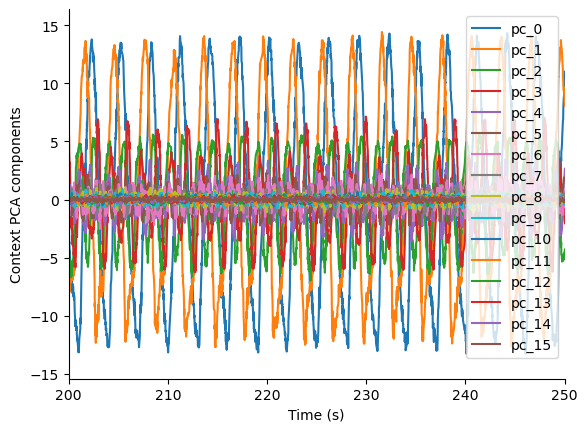

In [5]:
# example context trace
for i in range(context_dim):
    plt.plot(
        analysis.t,
        analysis.c_pca[:, i],
        label=f"pc_{i}",
    )
plt.legend(loc=1)
plt.xlabel("Time (s)")
plt.ylabel("Context PCA components")
plt.xlim(200, 250)
ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)

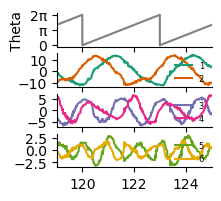

In [ ]:
fig, ax = plt.subplots(figsize=(2, 2), nrows=4, sharex=True)

window = (120, 130)
window = (119, 125)

ind = np.where((t >= window[0]) & (t <= window[1]))[0]
ax[0].plot(t[ind], theta[ind], c="grey")

ind = np.where((analysis.t >= window[0]) & (analysis.t <= window[1]))[0]
for i in range(6):
    color = f"C{i}"
    color = plt.cm.Dark2(i / 8)
    ax[i // 2 + 1].plot(
        analysis.t[ind], analysis.c_pca[ind, i], label=f"{i+1}", c=color
    )

plt.xlim(window[0], window[1])

for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[0].set_ylabel("Theta")
ax[0].set_yticks([0, np.pi, 2 * np.pi], labels=["0", "π", "2π"])

for a in ax[1:]:
    a.legend(fontsize=6, frameon=False, loc="upper right")

fig.savefig(figure_folder / "context_traces.svg")

## contex-phase relationship

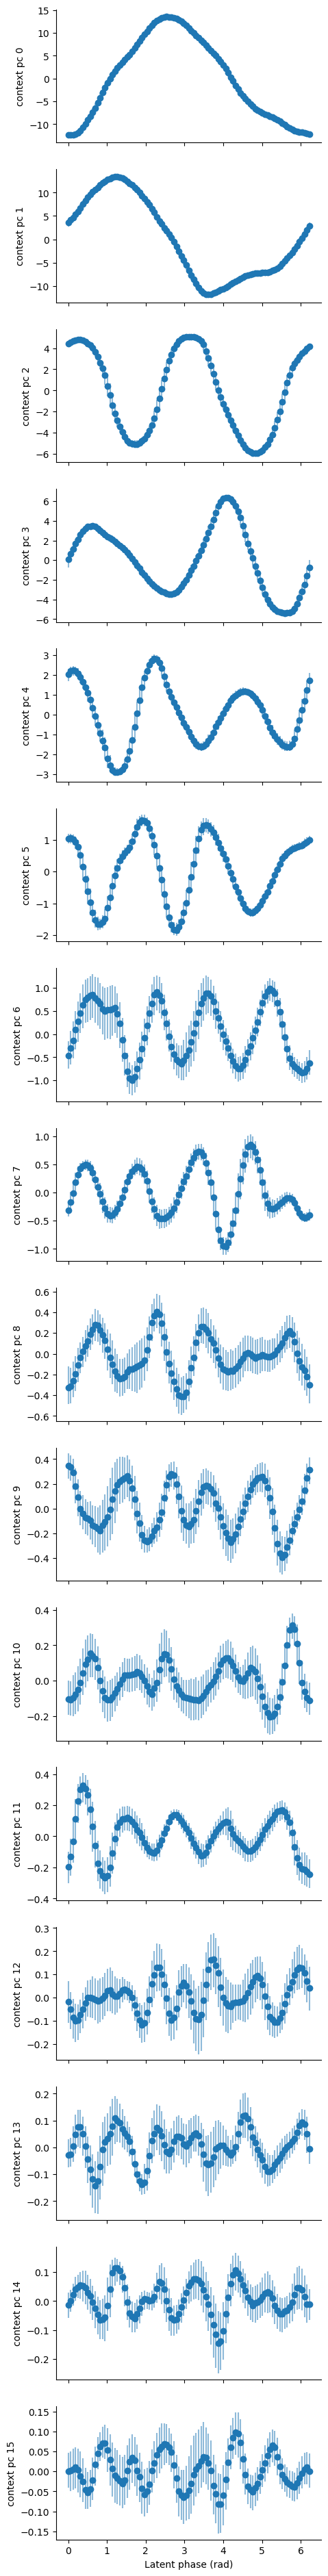

In [8]:
c_binned, bins = analysis.bin_context_by_feature(theta, t, pca=True, bins=100)

fig, ax = plt.subplots(
    nrows=context_dim, ncols=1, figsize=(5, 3 * context_dim), sharex=True
)

for i in range(context_dim):
    ax[i].scatter(bins[:-1], [np.nanmedian(cc[:, i]) for cc in c_binned])
    lo = [np.nanpercentile(cc[:, i], 25) for cc in c_binned]
    hi = [np.nanpercentile(cc[:, i], 75) for cc in c_binned]
    ax[i].vlines(bins[:-1], lo, hi, color="C0", alpha=0.5)
    ax[i].set_ylabel(f"context pc {i}")
    ax[i].spines[["top", "right"]].set_visible(False)

plt.xlabel("Latent phase (rad)")

fig.savefig(figure_folder / "single_modal_context_tuning_curves.svg")

## Context-phase: two column 

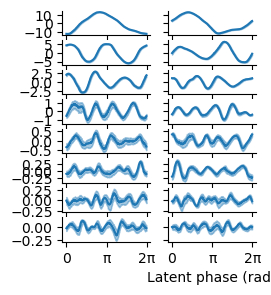

In [ ]:
c_binned, bins = analysis.bin_context_by_feature(theta, t, pca=True, bins=300)

fig, ax = plt.subplots(
    nrows=context_dim // 2, ncols=2, figsize=(2.5, 3), sharex=True, sharey="row"
)
ax = ax.flatten()
for i in range(context_dim):
    # ax[i].scatter(bins[:-1], [np.nanmedian(cc[:, i]) for cc in c_binned], s=5)
    lo = [np.nanpercentile(cc[:, i], 25) for cc in c_binned]
    hi = [np.nanpercentile(cc[:, i], 75) for cc in c_binned]
    # ax[i].vlines(bins[:-1], lo, hi, color="C0", alpha=0.5)

    ax[i].plot(bins[:-1], [np.nanmedian(cc[:, i]) for cc in c_binned])
    ax[i].fill_between(bins[:-1], lo, hi, color="C0", alpha=0.4)

    # ax[i].set_ylabel(f"context pc {i}")
    ax[i].spines[["top", "right"]].set_visible(False)

for a in ax[-2:]:
    a.set_xticks([0, np.pi, 2 * np.pi], labels=["0", "π", "2π"])
plt.xlabel("Latent phase (rad)")

fig.savefig(figure_folder / "single_modal_context_tuning_curves_2column.svg")

([<matplotlib.axis.YTick at 0x7f5b184a0e20>,
 [Text(0, 0, '1'), Text(0, 15, '16')])

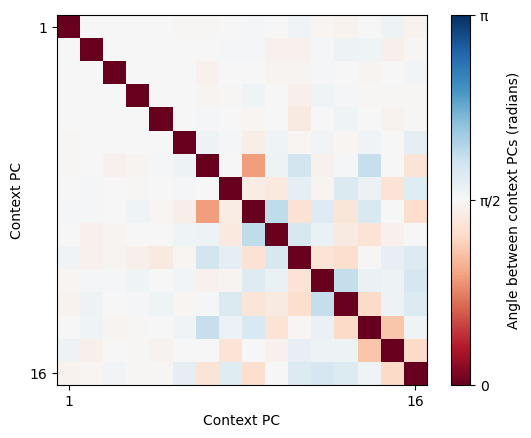

In [ ]:
c_mid = np.array([np.nanmean(cc[:, :], axis=0) for cc in c_binned])
sim_matrix = np.zeros((context_dim, context_dim))


def angle_between_vectors(u, v):
    """
    Calculates the angle in radians between two vectors u and v.
    """
    # Normalize the vectors to get unit vectors
    unit_u = u / np.linalg.norm(u)
    unit_v = v / np.linalg.norm(v)

    # Compute the dot product of the unit vectors (which is cos(theta))
    cos_theta = np.dot(unit_u, unit_v)

    # Clip values to the valid range [-1, 1] for arccos due to potential floating point errors
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    # Calculate the angle in radians using arccos
    angle_rad = np.arccos(cos_theta)

    return angle_rad


for i in range(context_dim):
    for j in range(context_dim):
        # sim_matrix[i, j] = np.corrcoef(c_mid[:, i], c_mid[:, j])[0, 1]
        # val = np.corrcoef(c_mid[:, i], c_mid[:, j])[0, 1]
        # val = np.arccos(val) / np.pi
        # sim_matrix[i, j] = val
        sim_matrix[i, j] = angle_between_vectors(c_mid[:, i], c_mid[:, j])


plt.imshow(sim_matrix, cmap="RdBu", clim=(0, np.pi))
cm = plt.colorbar(label="Angle between context PCs (radians)")
cm.set_ticks([0, np.pi / 2, np.pi])
cm.set_ticklabels(["0", "π/2", "π"])

plt.xlabel("Context PC")
plt.ylabel("Context PC")
plt.xticks([0, context_dim - 1], [1, context_dim])
plt.yticks([0, context_dim - 1], [1, context_dim])

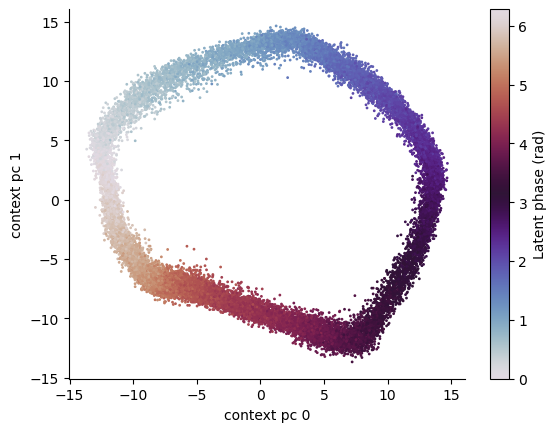

In [130]:
# Context embedding
fig = plt.figure()
subset = 10
mark_phase_ind = np.digitize(analysis.t, t) - 1
mark_phase = theta[mark_phase_ind]
plt.scatter(
    analysis.c_pca[::subset, 0],
    analysis.c_pca[::subset, 1],
    c=mark_phase[::subset],
    s=1,
    cmap="twilight",
    rasterized=True,
)
plt.xlabel("context pc 0")
plt.ylabel("context pc 1")
ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)
plt.colorbar(label="Latent phase (rad)")

fig.savefig(figure_folder / "single_modal_context_phase_embedding_first_pcs.svg")

### Waveform embedding (Codes for tuning information, NOT waveform voltages)

In [ ]:
analysis.params["params"].keys()  # ["rate_prediction"]["W_0"]

dict_keys(['embedding'])

/tmp/ipykernel_2755015/1156536120.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=1)


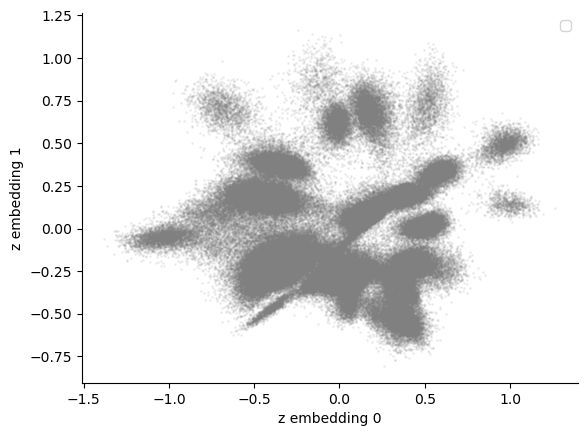

In [136]:
z = analysis.z.copy()
# W = np.array(params["params"]["rate_prediction"]["W_0"])
# z = z @ W
# pca = analysis.pca
# ind = ~np.isnan(z).any(axis=1)

# pc_components = pca.components_
# z = z @ pc_components.T
# z[ind] = pca.transform(z[ind])

subset = 1

from sklearn.decomposition import PCA

pca = PCA(n_components=z.shape[-1])

ind_valid = ~np.isnan(z).any(axis=1)
pca.fit(z[ind_valid])
# pca = analysis.pca
z[ind_valid] = pca.transform(z[ind_valid])

ids = mark_ids[1:]
# feature = template_waveforms[ids].argmax(axis=1)
plt.scatter(
    z[::subset, 0], z[::subset, 1], s=1, alpha=0.1, c="grey"
)  # c=feature, cmap="jet")

ind_noise = np.where(ids > mark_ids.max() - n_noise_units)[0][::subset]
# plt.scatter(
#     z[ind_noise, 0], z[ind_noise, 1], s=1, alpha=0.2, c="green", label="Noise units"
# )
# plt.colorbar(label="Channel of max amplitude")
plt.xlabel("z embedding 0")
plt.ylabel("z embedding 1")
plt.legend(loc=1)
ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)

# plt.title("Waveform Embedding NOT organized by waveform shape")

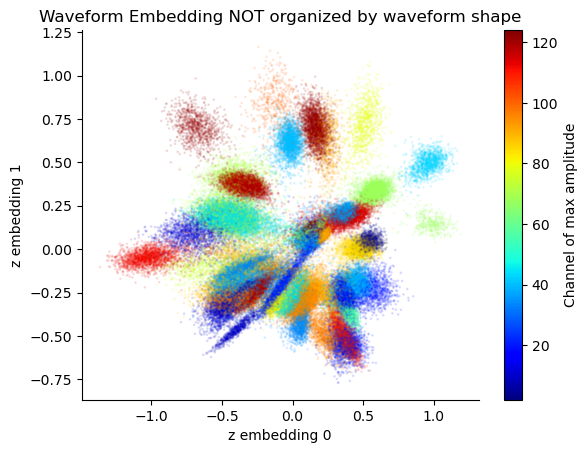

In [137]:
# z = analysis.z
# z = pca.transform(z)
subset = 2


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ids = mark_ids[1:]
feature = template_waveforms[ids].argmax(axis=1)[::subset]
sc = plt.scatter(
    z[::subset, 0],
    z[::subset, 1],
    s=1,
    alpha=0.1,
    c=feature,
    cmap="jet",
    rasterized=True,
)
cbar = plt.colorbar(sc, label="Channel of max amplitude")
cbar.solids.set_alpha(1)

plt.xlabel("z embedding 0")
plt.ylabel("z embedding 1")
plt.title("Waveform Embedding NOT organized by waveform shape")

ax.spines[["top", "right"]].set_visible(False)

fig.savefig(
    figure_folder / "single_modal_z_embedding_waveforms.svg",
)

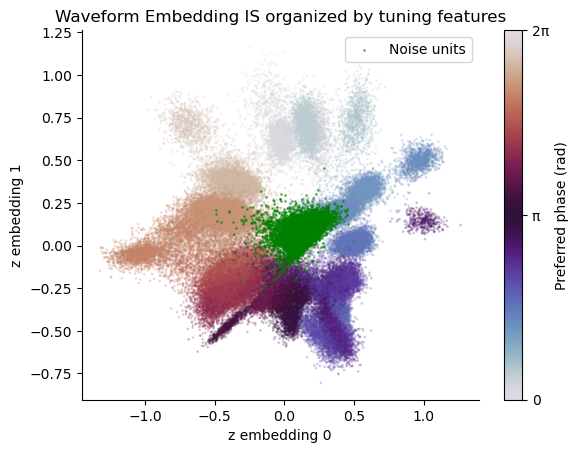

In [138]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ids = mark_ids[1:]

ind = np.where(ids < mark_ids.max() - n_noise_units)[0][::subset]
feature = tuning_curves["theta_max"][ids]

ind = np.where(ids < mark_ids.max() - n_noise_units)[0][::subset]
sc = plt.scatter(
    z[ind, 0],
    z[ind, 1],
    s=1,
    alpha=0.2,
    c=feature[ind],
    cmap="twilight",
    rasterized=True,
    clim=(0, 2 * np.pi),
)
cbar = plt.colorbar(
    sc,
    label="Preferred phase (rad)",
)
cbar.solids.set_alpha(1)
cbar.set_ticks([0, np.pi, 2 * np.pi])
cbar.set_ticklabels(["0", "π", "2π"])

ind = np.where(ids > mark_ids.max() - n_noise_units)[0]
noise_color = "green"
plt.scatter(
    z[ind, 0],
    z[ind, 1],
    s=1,
    alpha=0.5,
    c=noise_color,
    label="Noise units",
    rasterized=True,
)
plt.legend(loc=1)


plt.xlabel("z embedding 0")
plt.ylabel("z embedding 1")

plt.title("Waveform Embedding IS organized by tuning features")

ax.spines[["top", "right"]].set_visible(False)
fig.savefig(figure_folder / "single_modal_z_embedding_tuning.svg")

In [139]:
i = 12  # example neuron # good for 8d model
# i =2

# Find neuron with similar tuning curve
peak = tuning_curves["theta_max"][i]
target_peak = peak - 0.5
i_tuning = np.argmin((tuning_curves["theta_max"][:-n_noise_units] - target_peak) ** 2)

# Find neuron with similar waveform
peak = np.argmax(template_waveforms[i])
target_peak = peak + 10
i_waveform = np.argmin(
    (template_waveforms.argmax(axis=1)[:-n_noise_units] - target_peak) ** 2
)

samples = [i, i_tuning, i_waveform, n_units - 1]
noise_color = "green"
colors = ["red", "C1", "C34", noise_color]

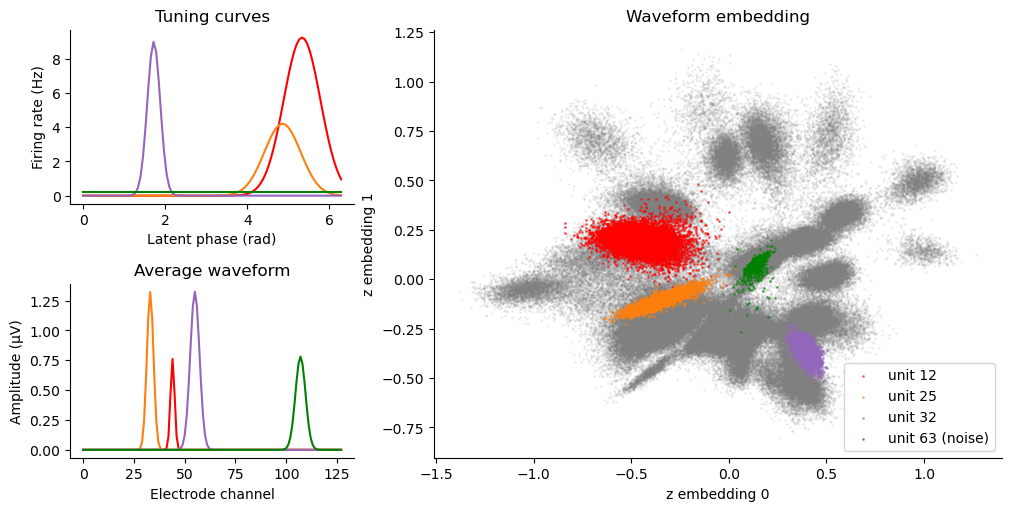

In [140]:
from matplotlib.gridspec import GridSpec
from src.c3po.toy_model_generators.phase import gaussian

fig = plt.figure(constrained_layout=True, figsize=(10, 5))
gs = GridSpec(2, 3, figure=fig)
tuning_ax = fig.add_subplot(gs[0, 0])
waveform_ax = fig.add_subplot(gs[1, 0])
embedding_ax = fig.add_subplot(gs[:, 1:])

ids = mark_ids[1:]
for i_, color in zip(samples, colors):
    theta_bins = np.linspace(0, 2 * np.pi, 100)
    tuning_curve_i = (
        gaussian(theta_bins, tuning_curves["theta_max"][i_], tuning_curves["sigma"][i_])
        * tuning_curves["amplitude"][i_]
    )
    if i_ >= n_units - n_noise_units:
        rate = np.where(ids == i_)[0].shape[0] / (t_max)
        tuning_curve_i = np.ones_like(tuning_curve_i) * rate

    tuning_ax.plot(theta_bins, tuning_curve_i, c=color, label=f"unit {i_}")

    waveform_ax.plot(
        template_waveforms[i_].T,
        c=color,
    )

# z = analysis.z
ids = mark_ids[1:]
embedding_ax.scatter(z[:, 0], z[:, 1], s=1, alpha=0.1, c="grey", rasterized=True)
for i_, c_ in zip(samples, colors):
    embedding_ax.scatter(
        z[ids == i_, 0],
        z[ids == i_, 1],
        s=1,
        alpha=0.5,
        c=c_,
        label=f"unit {i_}{' (noise)' if i_ >= n_units - n_noise_units else ''}",
        rasterized=True,
    )

tuning_ax.set_xlabel("Latent phase (rad)")
tuning_ax.set_ylabel("Firing rate (Hz)")
tuning_ax.spines[["top", "right"]].set_visible(False)
tuning_ax.set_title("Tuning curves")

waveform_ax.set_xlabel("Electrode channel")
waveform_ax.set_ylabel("Amplitude (µV)")
waveform_ax.spines[["top", "right"]].set_visible(False)
waveform_ax.set_title("Average waveform")

embedding_ax.set_xlabel("z embedding 0")
embedding_ax.set_ylabel("z embedding 1")
embedding_ax.spines[["top", "right"]].set_visible(False)
embedding_ax.set_title("Waveform embedding")
embedding_ax.legend(loc=4)

fig.savefig(figure_folder / "single_modal_unit_comparison.svg")

# Tuning Curve bases

In [47]:
pca_ = False
from src.c3po.toy_model_generators.phase import firing_rate

real_curves = []
inferred_curves = []
c_binned, bins = analysis.bin_context_by_feature(theta, t, pca=pca_, bins=100)
c_binned_pca, bins = analysis.bin_context_by_feature(theta, t, pca=True, bins=100)

z_mean_all = []
z_mean_pca_all = []

for neuron_i in range(n_units - n_noise_units):
    i_ = neuron_i
    ind_marks = np.where(mark_ids[1:] == neuron_i)[0]

    pc_componenents = analysis.pca.components_
    z_neuron = analysis.z[ind_marks].copy()
    z_neuron_pca = z_neuron @ pc_componenents.T

    z_mean = np.nanmean(z_neuron, axis=0)
    z_mean_pca = np.nanmean(z_neuron_pca, axis=0)

    z_mean_all.append(z_mean)
    z_mean_pca_all.append(z_mean_pca)

    # # z_neuron = z_neuron @ pc_components.T
    # plt.scatter(z_neuron[:, 0], z_neuron[:, 1], s=1, alpha=0.5, c="red")

    # i_ = 12
    # plt.scatter(z[ids == i_, 1],z[ids == i_, 0],)
    context_dim = analysis.context_dim

    c_bases = [[np.nanmean(cc[:, i]) for cc in c_binned] for i in range(context_dim)]
    c_bases = np.array(c_bases)
    c_bases_pca = [
        [np.nanmean(cc[:, i]) for cc in c_binned_pca] for i in range(context_dim)
    ]
    c_bases_pca = np.array(c_bases_pca)

    if pca_:
        inferred_field = z_mean_pca[:, None] * c_bases
    else:
        inferred_field = z_mean[:, None] * c_bases
    inferred_field = inferred_field.sum(axis=0)

    inferred_field = np.exp(inferred_field)
    phase_inferred = bins[:-1]
    # plt.plot(phase_inferred, inferred_field)

    theta_bins = np.linspace(0, 2 * np.pi, 100)
    # tuning_curve_i = (
    #     gaussian(theta_bins, tuning_curves["theta_max"][i_], tuning_curves["sigma"][i_])
    #     * tuning_curves["amplitude"][i_]
    # )
    tuning_curve_i = firing_rate(
        theta_bins,
        tuning_curves["theta_max"][i_],
        tuning_curves["sigma"][i_],
        tuning_curves["amplitude"][i_],
    )

    real_curves.append(tuning_curve_i)
    inferred_curves.append(inferred_field)


real_curves = np.array(real_curves)
inferred_curves = np.array(inferred_curves)

z_mean_all = np.array(z_mean_all)
z_mean_pca_all = np.array(z_mean_pca_all)
# tuning_curve_i = np.log(tuning_curve_i + 1e-3)  # add small constant to avoid log(0)
# plt.plot(theta_bins, tuning_curve_i)
# inferred_curves = inferred_curves / inferred_curves.max(axis=1, keepdims=True)

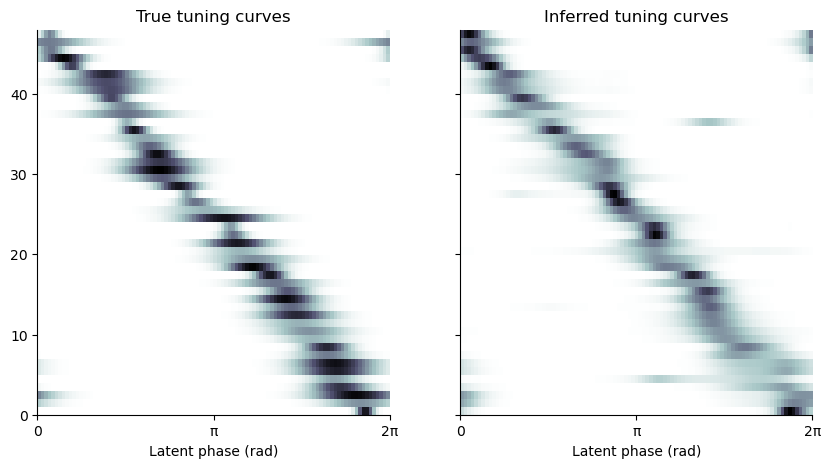

In [48]:
ind = np.argsort(np.argmax(real_curves, axis=1))
fig, ax = plt.subplots(ncols=2, sharey=True, sharex=True, figsize=(10, 5))

ax[0].imshow(
    np.array(real_curves)[ind],
    aspect="auto",
    extent=[0, 2 * np.pi, 0, n_units - n_noise_units],
    cmap="bone_r",
)
ax[0].set_title("True tuning curves")
ax[0].set_xlabel("Latent phase (rad)")

ax[1].imshow(
    np.array(inferred_curves / inferred_curves.mean(axis=1, keepdims=True))[ind],
    aspect="auto",
    extent=[0, 2 * np.pi, 0, n_units - n_noise_units],
    cmap="bone_r",
)
ax[1].set_title("Inferred tuning curves")
ax[1].set_xlabel("Latent phase (rad)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
    a.set_xticks([0, np.pi, 2 * np.pi])
    a.set_xticklabels(["0", "π", "2π"])

fig.savefig(figure_folder / "single_modal_tuning_curve_comparison.svg")

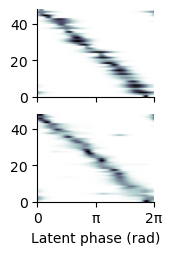

In [ ]:
ind = np.argsort(np.argmax(real_curves, axis=1))
fig, ax = plt.subplots(nrows=2, sharey=True, sharex=True, figsize=(1.5, 2.5))

ax[0].imshow(
    np.array(real_curves)[ind],
    aspect="auto",
    extent=[0, 2 * np.pi, 0, n_units - n_noise_units],
    cmap="bone_r",
)
# ax[0].set_title("True tuning curves")
# ax[0].set_xlabel("Latent phase (rad)")

ax[1].imshow(
    np.array(inferred_curves / inferred_curves.mean(axis=1, keepdims=True))[ind],
    aspect="auto",
    extent=[0, 2 * np.pi, 0, n_units - n_noise_units],
    cmap="bone_r",
)
# ax[1].set_title("Inferred tuning curves")
ax[1].set_xlabel("Latent phase (rad)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
    a.set_xticks([0, np.pi, 2 * np.pi])
    a.set_xticklabels(["0", "π", "2π"])

fig.savefig(figure_folder / "single_modal_tuning_curve_comparison_vertical.svg")

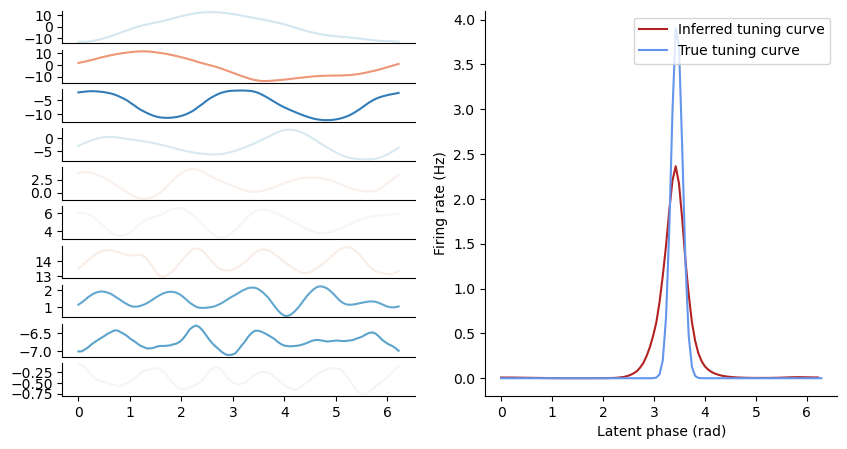

In [28]:
example_neuron = 4

fig = plt.figure(figsize=(10, 5))
ax_result = fig.add_subplot(1, 2, 2)
ax_components = []
for i in range(10):
    ax = fig.add_subplot(10, 2, 2 * i + 1)
    ax_components.append(ax)

z_mean_pca = z_mean_pca_all[example_neuron]

c_bases_pca = c_bases.T @ analysis.pca.components_.T
cumulative = np.zeros(c_bases_pca.shape[0])
for i in range(context_dim):
    val = c_bases_pca[:, i] * z_mean_pca[i]
    cumulative += val
    if i < len(ax_components):
        val = c_bases_pca[:, i]
        # val = np.exp(val)
        c_val = (z_mean_pca[i] + 1) / 2
        c_val = z_mean_pca[i] + 0.5
        color = plt.cm.RdBu(c_val)
        # color = plt.cm.coolwarm(c_val)
        # color = plt.cm.RdYlGn(c_val)
        ax_components[i].plot(phase_inferred, val, label=f"PC {i}", c=color)
    # plt.plot(c_bases_pca[:, i] * z_mean_pca[i], label=f"PC {i}")


ax_result.plot(
    phase_inferred, np.exp(cumulative), label="Inferred tuning curve", c="firebrick"
)
ax_result.plot(
    theta_bins,
    (real_curves[example_neuron]),
    label="True tuning curve",
    c="cornflowerblue",
)
ax_result.legend()

# ylim=(-10,5)
for ax in ax_components[:]:
    ax.spines[["top", "right"]].set_visible(False)
    # ax.set_ylim(ylim)

for ax in ax_components[:-1]:
    ax.set_xticks([])

ax_result.set_xlabel("Latent phase (rad)")
ax_result.set_ylabel("Firing rate (Hz)")
ax_result.spines[["top", "right"]].set_visible(False)

In [110]:
z_mean_pca

array([-0.06285975, -0.51750651, -0.31034776, -0.13441317,  0.08670678,
       -0.05138644, -0.01177417,  0.03306915,  0.03806597,  0.08418232,
        0.00157374,  0.08477495, -0.13894518,  0.09747812, -0.1099322 ,
       -0.08961177])

# Example raster plot

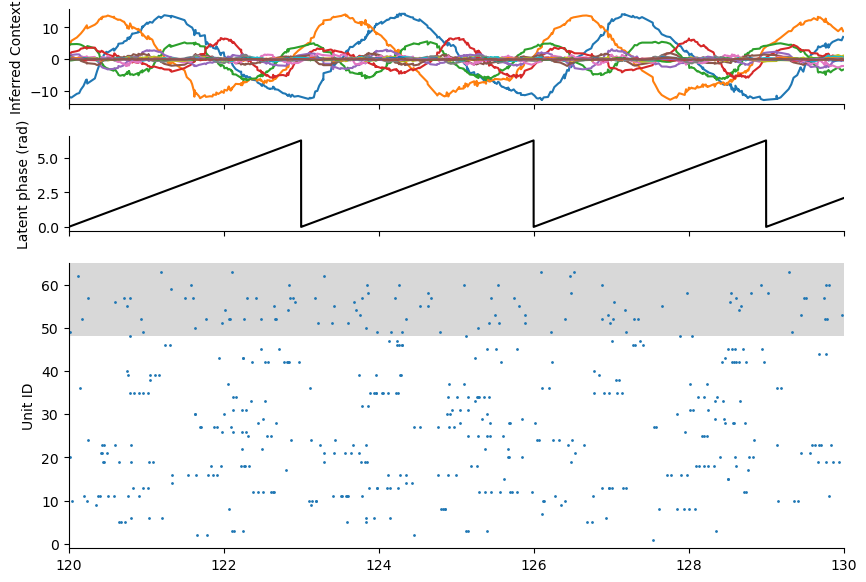

In [45]:
interval = (120, 130)

fig, ax = plt.subplots(figsize=(10, 7), nrows=3, sharex=True, height_ratios=[1, 1, 3])

# raster
ind = np.where((mark_times >= interval[0]) & (mark_times <= interval[1]))[0]
ax[2].plot(mark_times[ind], mark_ids[ind], ls="", marker=".", markersize=2)
ax[2].fill_between(
    [interval[0] - 0.3, interval[1] + 0.3],
    [n_units - n_noise_units, n_units - n_noise_units],
    [n_units + 1, n_units + 1],
    color="grey",
    edgecolor=None,
    alpha=0.3,
)
ax[2].set_ylim(-1, n_units + 1)

# phase
ind = np.logical_and(t >= interval[0], t <= interval[1])
ax[1].plot(t[ind], theta[ind], color="k")

# context
ind = np.logical_and(analysis.t >= interval[0], analysis.t <= interval[1])
ax[0].plot(
    analysis.t[ind],
    analysis.c_pca[ind, :],
)


ax[0].set_ylabel("Inferred Context")
ax[1].set_ylabel("Latent phase (rad)")
ax[2].set_ylabel("Unit ID")
ax[1].set_xlim(interval)
for a in ax:
    a.spines[["top", "right"]].set_visible(False)

fig.savefig(figure_folder / "single_modal_raster_context.svg")

Text(0, 0.5, 'channel')

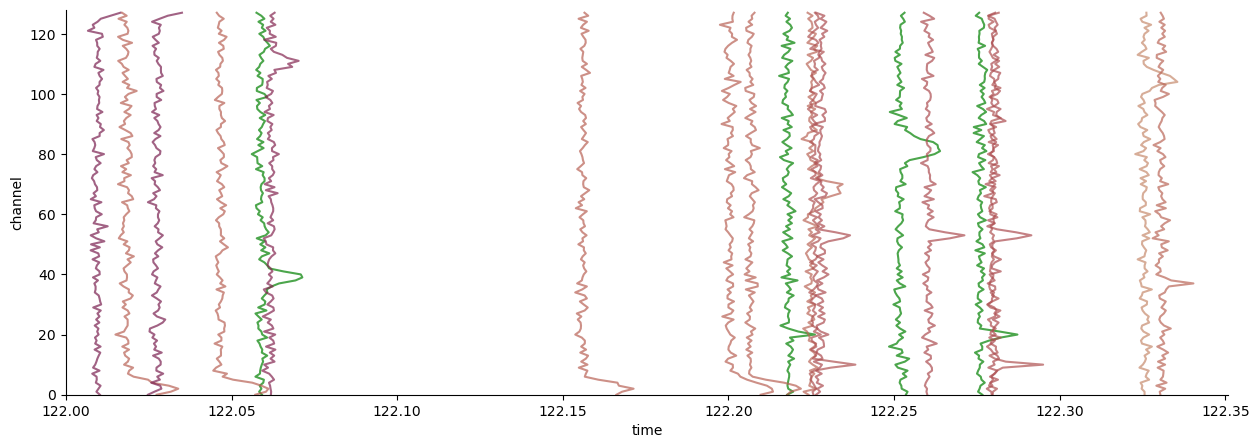

In [13]:
interval = (122, 130)

fig, ax = plt.subplots(figsize=(15, 5))

ind = np.where((mark_times >= interval[0]) & (mark_times <= interval[1]))[0]


for i in ind[:20]:
    t_i = mark_times[i]
    id_i = mark_ids[i]
    if id_i >= n_units - n_noise_units:
        c_i = "g"
        zorder = -1
    else:
        feature_i = tuning_curves["theta_max"][id_i]
        c_i = plt.cm.twilight(feature_i / (2 * np.pi))
        zorder = 1

    ax.plot(
        marks[i] / 100 + t_i,
        np.arange(n_channels),
        # c='grey',
        c=c_i,
        zorder=zorder,
        alpha=0.7,
    )

plt.xlim(interval[0], t_i + 0.02)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, n_channels)

plt.xlabel("time")
plt.ylabel("channel")

# Example raster Horizontal

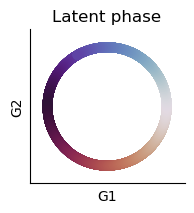

In [113]:
interval = (119, 127)

widths = [
    2,
]

fig, ax = plt.subplots(
    figsize=(2, 2), ncols=len(widths), sharex=True, width_ratios=widths
)
ax = [ax]
ind = np.logical_and(t >= interval[0], t <= interval[1])
c_val = (theta[ind]) / (2 * np.pi)
c = plt.cm.twilight(c_val)
ax[0].scatter(np.cos(theta[ind]), np.sin(theta[ind]), color=c, rasterized=True)
# theta_mark =
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title("Latent phase")
ax[0].set_xlabel("G1")
ax[0].set_ylabel("G2")
ax[0].spines[["top", "right"]].set_visible(False)
ax[0].set_xlim(-1.3, 1.3)
ax[0].set_ylim(-1.3, 1.3)

fig.savefig(figure_folder / "single_modal_latent_phase.svg")

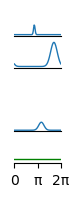

In [114]:
from src.c3po.toy_model_generators.phase import firing_rate

fig, ax = plt.subplots(figsize=(0.6, 2), ncols=1, nrows=5, sharey=True)

ax[2].set_axis_off()
ax = ax[[0, 1, 3, 4]]

neurons = [0, 12, 2, n_units - n_noise_units + 15]


for i, i_ in enumerate(neurons):
    theta_bins = np.linspace(0, 2 * np.pi, 100)
    tuning_curve_i = firing_rate(
        theta_bins,
        tuning_curves["theta_max"][i_],
        tuning_curves["sigma"][i_],
        tuning_curves["amplitude"][i_],
    )
    color = "C0" if i_ < n_units - n_noise_units else "green"
    if i_ >= n_units - n_noise_units:
        rate = np.mean(tuning_curve_i)
        tuning_curve_i = np.ones_like(tuning_curve_i) * rate + 1

    ax[i].plot(theta_bins, tuning_curve_i, c=color, lw=1)

    ax[i].spines[["top", "right"]].set_visible(False)
    # ax[i].spines["bottom"].set_visible(False)
    ax[i].set_xticks([])
    ax[i].set_xlim(0, 2 * np.pi)
    ax[i].spines["left"].set_visible(False)
    ax[i].set_yticks([])

a = ax[-1]
a.set_xticks([0, np.pi, 2 * np.pi])
a.set_xticklabels(["0", "π", "2π"])

fig.savefig(figure_folder / "single_modal_tuning_curves_horiz.svg")

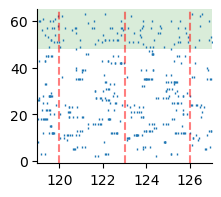

In [123]:
fig, ax = plt.subplots(
    figsize=(2.25, 2),
    nrows=1,
)


ind = np.where((mark_times >= interval[0]) & (mark_times <= interval[1]))[0]
ax.plot(mark_times[ind], mark_ids[ind], ls="", marker="|", markersize=2)
ax.fill_between(
    [interval[0] - 0.3, interval[1] + 0.3],
    [n_units - n_noise_units, n_units - n_noise_units],
    [n_units + 1, n_units + 1],
    color="green",
    edgecolor=None,
    alpha=0.15,
)

marks_ = t[(t % latent_period) < 0.001]
marks_ = marks_[(marks_ >= interval[0]) & (marks_ <= interval[1])]
for m in marks_:
    ax.axvline(m, color="red", ls="--", alpha=0.5)

ax.spines[["top", "right"]].set_visible(False)

ax.set_ylim(-1, n_units + 1)
ax.set_xlim(interval)

fig.savefig(figure_folder / "single_modal_raster_horiz.svg")

[120.01148668 120.02246685 120.04510652]


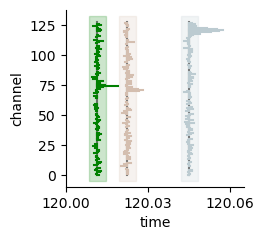

In [125]:
interval_zoom = (120, 120.06)

ind = np.where((mark_times >= interval_zoom[0]) & (mark_times <= interval_zoom[1]))[0]

print(mark_times[ind])

fig = plt.figure(
    figsize=(2.3, 2.3),
)
ax = fig.add_subplot(1, 1, 1)
for i in ind[:20]:
    t_i = mark_times[i]
    id_i = mark_ids[i]
    if id_i >= n_units - n_noise_units:
        c_i = "g"
        zorder = -1
    else:
        feature_i = tuning_curves["theta_max"][id_i]
        c_i = plt.cm.twilight(feature_i / (2 * np.pi))
        zorder = 1

    # ax.plot(
    #     marks[i] / 150 + t_i,
    #     np.arange(n_channels),
    #     # c='grey',
    #     c=c_i,
    #     zorder=zorder,
    #     alpha=0.7,
    # )

    mark_i = marks[i] / 120 + t_i
    ax.plot(
        [t_i, t_i],
        [0, n_channels],
        c="k",
        zorder=-2,
        alpha=0.5,
    )
    for i_chan, m in enumerate(mark_i):
        ax.plot(
            [t_i, m],
            [i_chan, i_chan],
            c=c_i,
            zorder=zorder,
            alpha=1,
        )

    sh = 0.003
    sh_y = 5
    ax.add_patch(
        plt.Rectangle(
            (t_i - sh, -sh_y),
            sh * 2,
            n_channels + 2 * sh_y,
            color=c_i,
            alpha=0.2,
            zorder=-3,
        )
    )


plt.xlim(interval_zoom[0], t_i + 0.02)

plt.xticks([120, 120.03, 120.06])
# plt.xticklabels(["120", "120.03", "120.06"])

ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(-10, n_channels + 10)

plt.xlabel("time")
plt.ylabel("channel")

fig.savefig(figure_folder / "single_modal_waveforms_horiz_zoom.svg")
# fig.savefig(figure_folder / "single_modal_waveforms_horiz.svg")

In [ ]:
print(figure_folder)

/home/sambray/Documents/c3po/Figures/Fig_1/periodic_toy_model_non_coding_units_v2_model_16d
